# Stage 3 — EDA, Feature Engineering & Dataset Preparation
**Dataset:** enhanced_dataset.csv (269 rows × 32 columns)
**Target:** Price (INR)

---
## 0. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

df = pd.read_csv('enhanced_dataset.csv')
print(f'Shape: {df.shape}')
df.head(3)

Matplotlib is building the font cache; this may take a moment.


Shape: (269, 32)


,Brand,Model,Variant / Trim,Make Year,Make Month,Registration Year,Car Age (years),Fuel Type,BS Norm,Transmission Type,...,Wear Score,Parts Evaluated,Meter Tampered,Flooded,Core Structure Intact,Next Service Due,Price (INR),Depreciation_Category,Value_Score,Country Of Origin
0,Tata,Nexon,XZ Plus (S),2021,Jan,2021,4,Petrol,NaN,Manual,...,8.7,1573.0,No,No,Yes,"12 months or 15,000 km",584800,High,7.0,India
1,Tata,Nexon,XZA Plus (S) Diesel,2021,Oct,2021,5,Diesel,BSVI,Automatic,...,8.6,1432.0,No,No,Yes,"12 months or 15,000 km",598400,High,6.2,India
2,Hyundai,Venue,SX Plus 1.0 Turbo DCT,2019,Sep,2019,6,Petrol,BSIV,Automatic,...,8.0,1452.0,No,No,Yes,No immediate servicing required,618400,High,7.9,South Korea


---
## 1. Initial Overview

In [2]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0])

=== Data Types ===
Brand                            str
Model                            str
Variant / Trim                   str
Make Year                      int64
Make Month                       str
Registration Year              int64
Car Age (years)                int64
Fuel Type                        str
BS Norm                          str
Transmission Type                str
Transmission Subtype             str
Kilometres Driven              int64
Number of Previous Owners        str
Insurance Validity               str
Insurance Type                   str
RTO                              str
Car Location                     str
Overall Quality Score        float64
Engine Score                 float64
Systems Score                float64
Interior Score               float64
Exterior Score               float64
Wear Score                   float64
Parts Evaluated              float64
Meter Tampered                   str
Flooded                          str
Core Structure Inta

In [3]:
print('=== Price (INR) Basic Stats ===')
print(df['Price (INR)'].describe())
print('\n=== Suspicious low-price rows ===')
print(df[df['Price (INR)'] < 10000][['Brand','Model','Price (INR)']])

=== Price (INR) Basic Stats ===
count    2.690000e+02
mean     8.129969e+05
std      4.059892e+05
min      4.000000e+00
25%      6.048000e+05
50%      8.008000e+05
75%      9.600000e+05
max      3.676286e+06
Name: Price (INR), dtype: float64

=== Suspicious low-price rows ===
             Brand    Model  Price (INR)
35       MG Motors   Hector           95
37       MG Motors   Hector           11
45            Tata    Nexon            7
78       MG Motors   Hector           11
104  Maruti Suzuki    Fronx          452
146        Hyundai  Alcazar          104
155          Honda     WR-V            4
170      MG Motors   Hector         9535
183            Kia    Sonet           53
239      MG Motors   Hector           12
262       Mahindra      XUV           43


---
## 2. EDA — Visualisations

### 2.1 Price Distribution

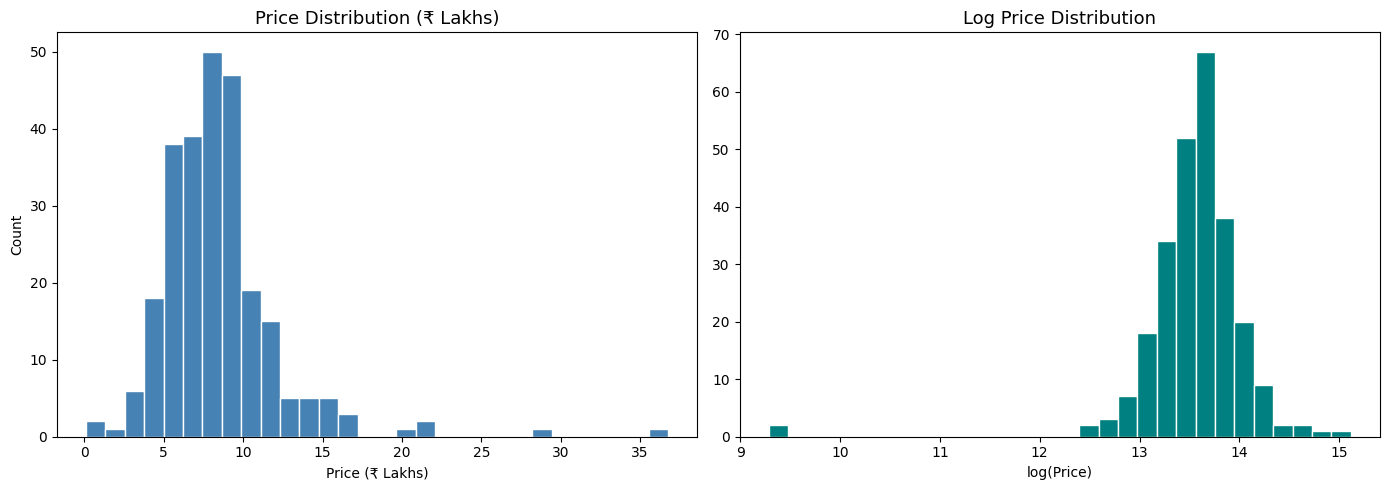

Skewness of Price: 2.728


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw price
df_clean_price = df[df['Price (INR)'] >= 10000]
axes[0].hist(df_clean_price['Price (INR)'] / 1e5, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (₹ Lakhs)')
axes[0].set_xlabel('Price (₹ Lakhs)')
axes[0].set_ylabel('Count')

# Log price
axes[1].hist(np.log1p(df_clean_price['Price (INR)']), bins=30, color='teal', edgecolor='white')
axes[1].set_title('Log Price Distribution')
axes[1].set_xlabel('log(Price)')

plt.tight_layout()
plt.savefig('plot_01_price_distribution.png', dpi=150)
plt.show()
print('Skewness of Price:', round(df_clean_price['Price (INR)'].skew(), 3))

### 2.2 Price vs Categorical Features

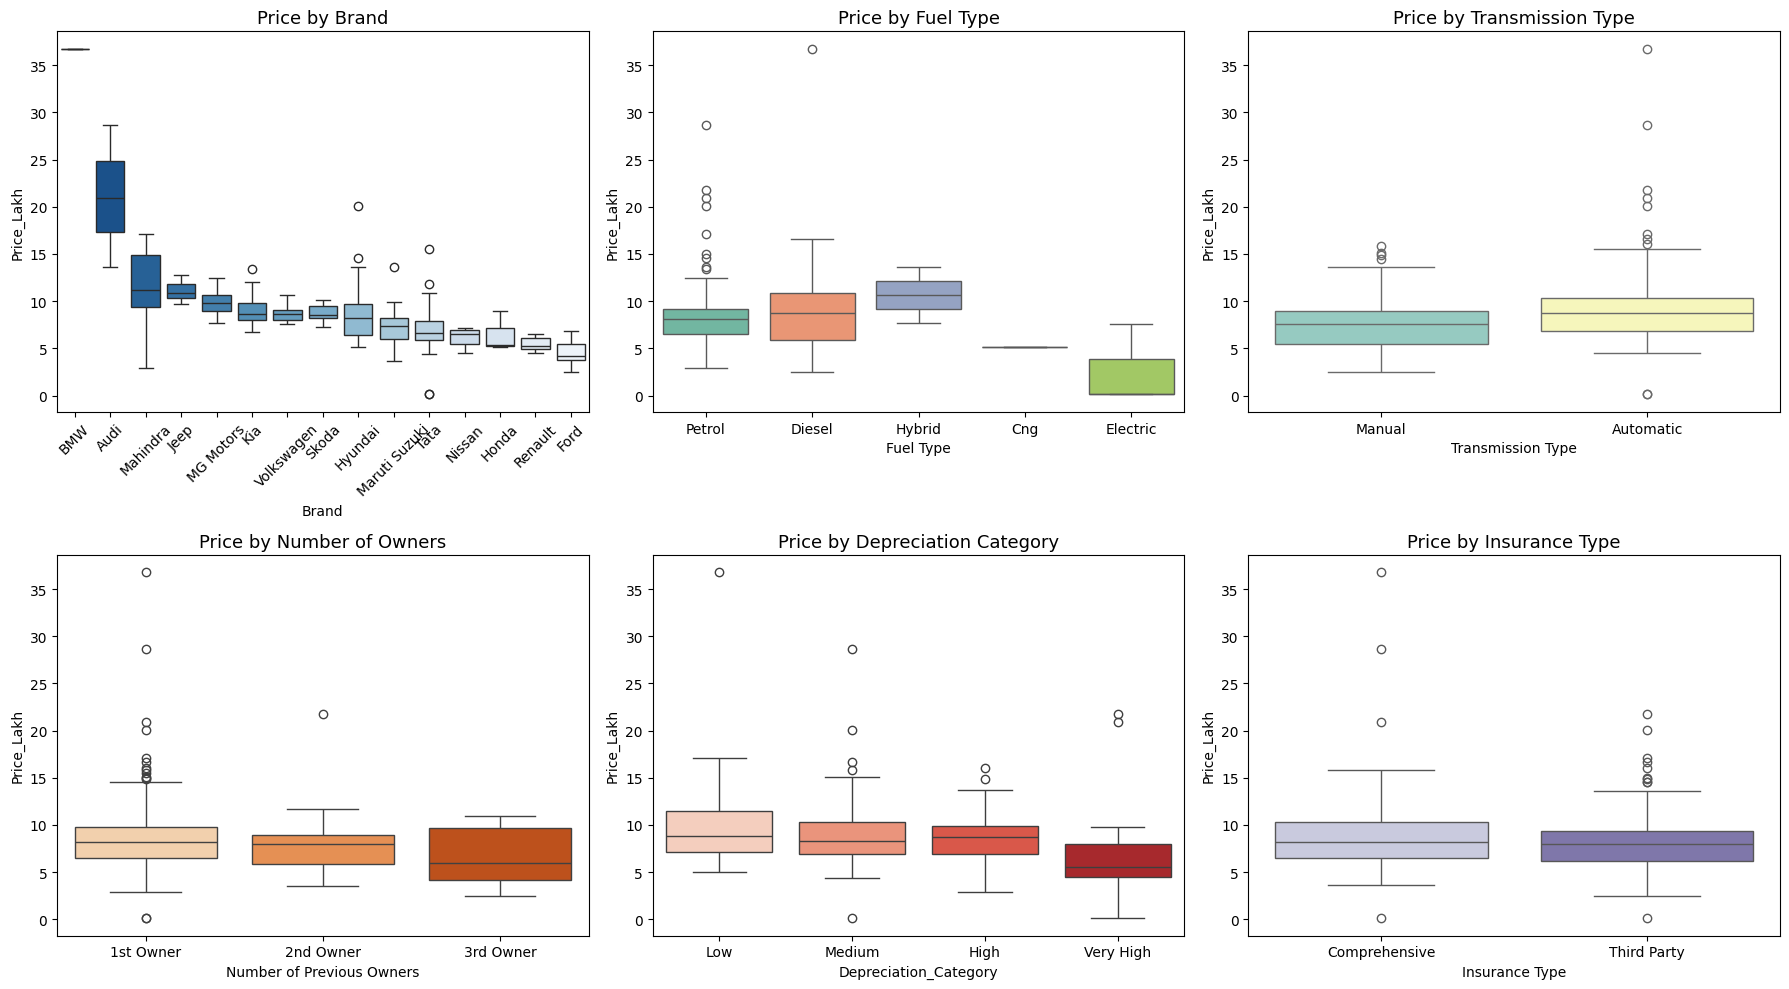

In [5]:
df_v = df[df['Price (INR)'] >= 10000].copy()
df_v['Price_Lakh'] = df_v['Price (INR)'] / 1e5

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Brand
brand_order = df_v.groupby('Brand')['Price_Lakh'].median().sort_values(ascending=False).index
sns.boxplot(data=df_v, x='Brand', y='Price_Lakh', order=brand_order, ax=axes[0,0], palette='Blues_r')
axes[0,0].set_title('Price by Brand')
axes[0,0].tick_params(axis='x', rotation=45)

# Fuel Type
sns.boxplot(data=df_v, x='Fuel Type', y='Price_Lakh', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Price by Fuel Type')

# Transmission
sns.boxplot(data=df_v, x='Transmission Type', y='Price_Lakh', ax=axes[0,2], palette='Set3')
axes[0,2].set_title('Price by Transmission Type')

# Number of Previous Owners
owner_order = ['1st Owner', '2nd Owner', '3rd Owner']
sns.boxplot(data=df_v, x='Number of Previous Owners', y='Price_Lakh', order=owner_order, ax=axes[1,0], palette='Oranges')
axes[1,0].set_title('Price by Number of Owners')

# Depreciation Category
dep_order = ['Low', 'Medium', 'High', 'Very High']
sns.boxplot(data=df_v, x='Depreciation_Category', y='Price_Lakh', order=dep_order, ax=axes[1,1], palette='Reds')
axes[1,1].set_title('Price by Depreciation Category')

# Insurance Type
sns.boxplot(data=df_v, x='Insurance Type', y='Price_Lakh', ax=axes[1,2], palette='Purples')
axes[1,2].set_title('Price by Insurance Type')

plt.tight_layout()
plt.savefig('plot_02_price_vs_categoricals.png', dpi=150)
plt.show()

### 2.3 Price vs Numerical Features

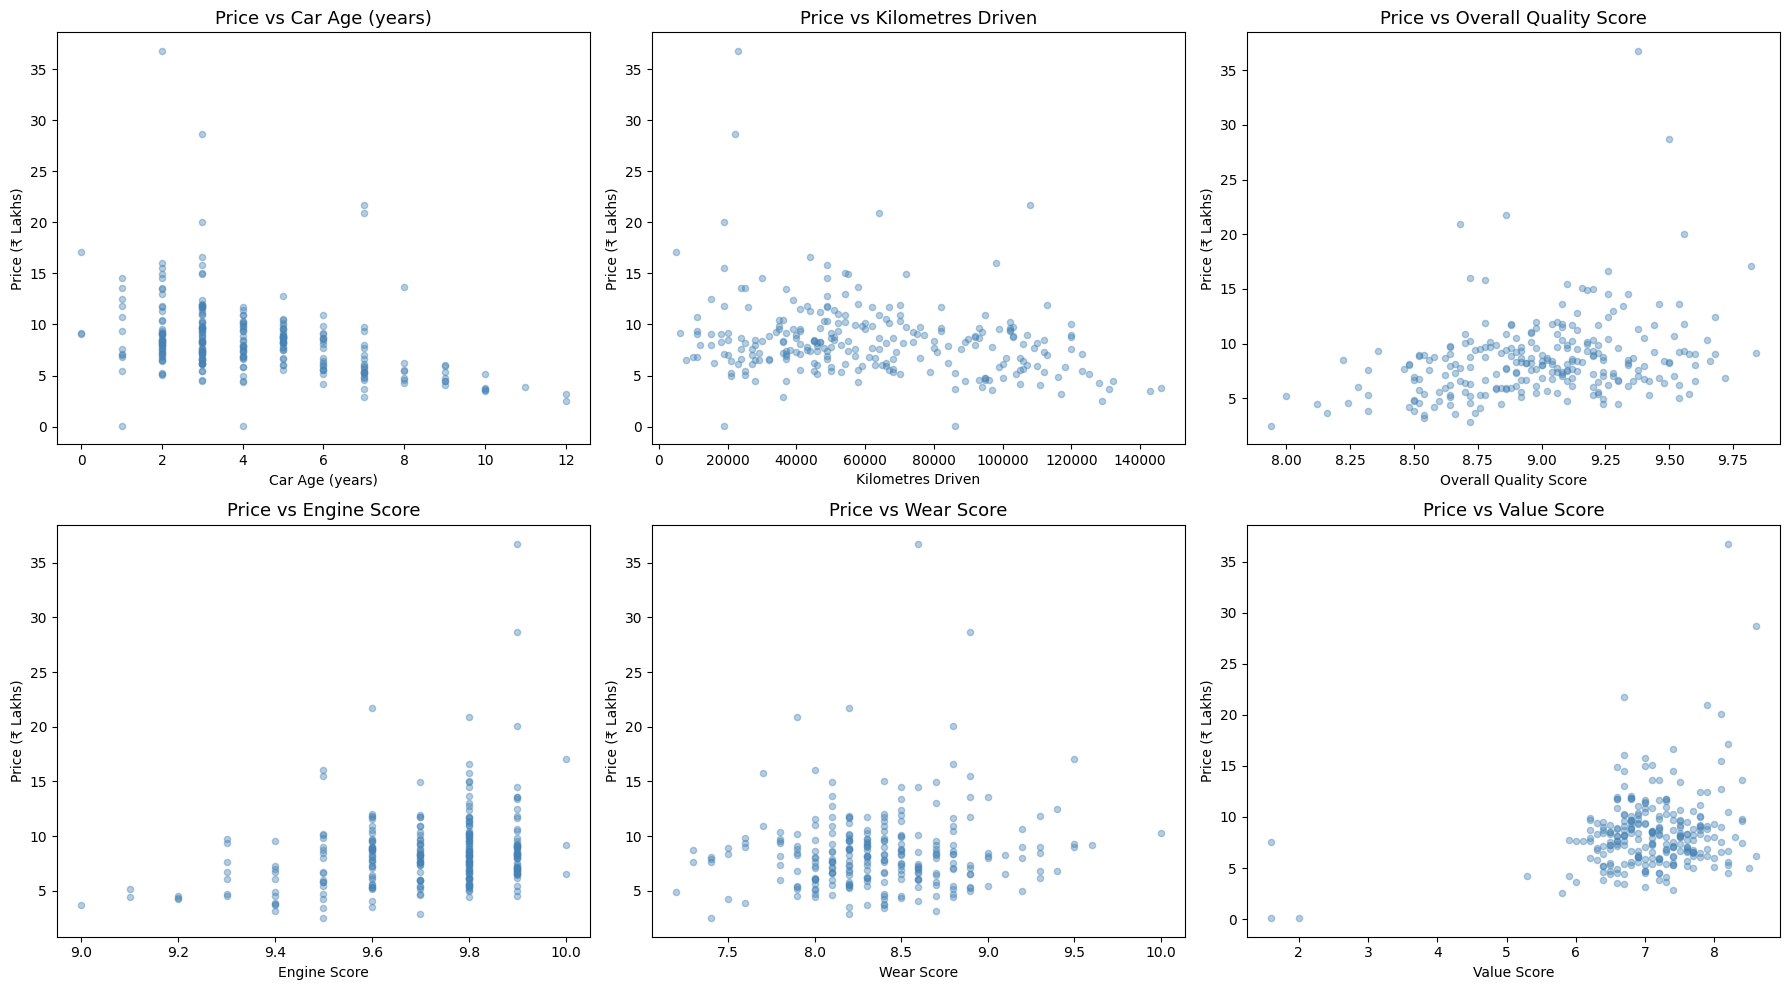

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

num_features = [
    ('Car Age (years)',    'Car Age (years)'),
    ('Kilometres Driven',  'Kilometres Driven'),
    ('Overall Quality Score', 'Overall Quality Score'),
    ('Engine Score',       'Engine Score'),
    ('Wear Score',         'Wear Score'),
    ('Value_Score',        'Value Score'),
]

for ax, (col, label) in zip(axes.flatten(), num_features):
    ax.scatter(df_v[col], df_v['Price_Lakh'], alpha=0.4, color='steelblue', s=20)
    ax.set_xlabel(label)
    ax.set_ylabel('Price (₹ Lakhs)')
    ax.set_title(f'Price vs {label}')

plt.tight_layout()
plt.savefig('plot_03_price_vs_numericals.png', dpi=150)
plt.show()

### 2.4 Correlation Heatmap

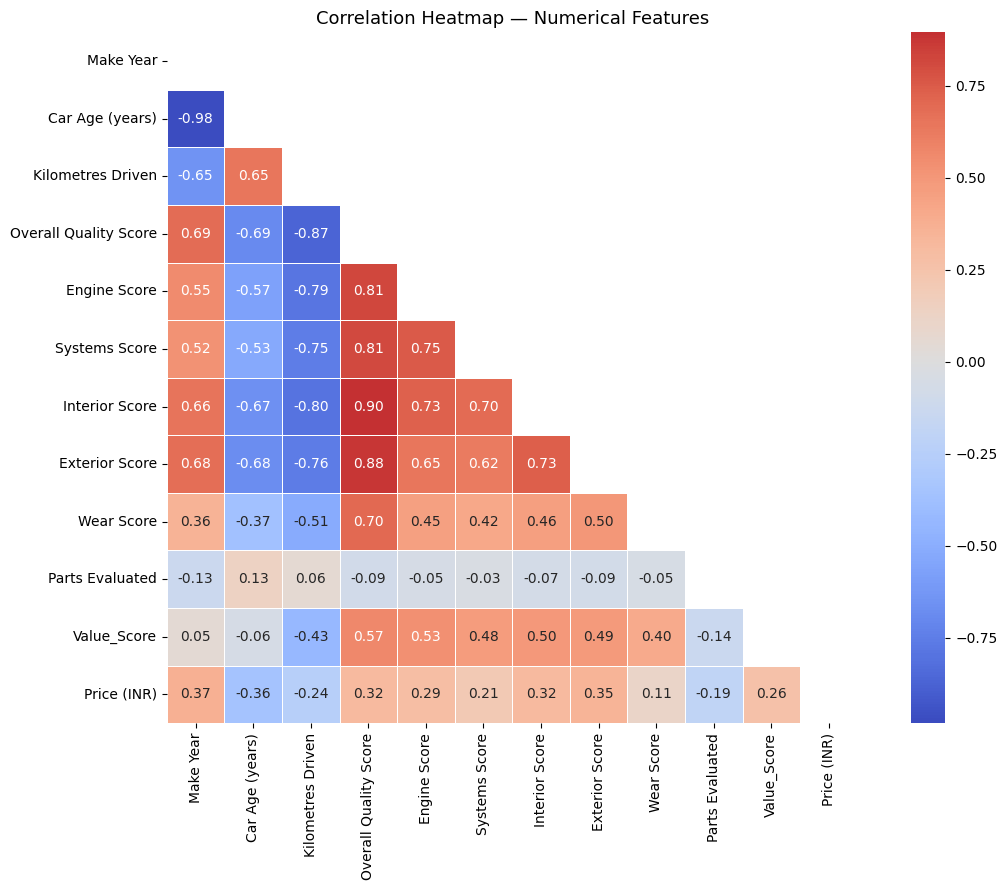

In [7]:
num_cols = [
    'Make Year', 'Car Age (years)', 'Kilometres Driven',
    'Overall Quality Score', 'Engine Score', 'Systems Score',
    'Interior Score', 'Exterior Score', 'Wear Score',
    'Parts Evaluated', 'Value_Score', 'Price (INR)'
]
corr = df_v[num_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.savefig('plot_04_correlation_heatmap.png', dpi=150)
plt.show()

### 2.5 Brand & Make Year Counts

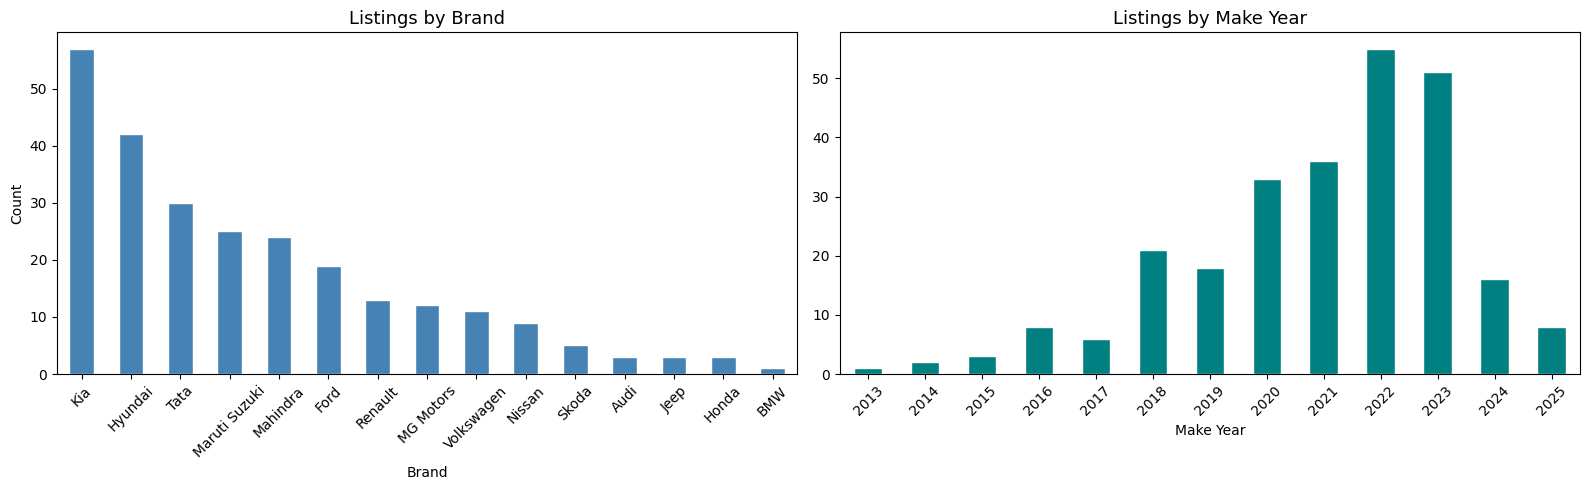

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_v['Brand'].value_counts().plot.bar(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Listings by Brand')
axes[0].set_xlabel('Brand')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

df_v['Make Year'].value_counts().sort_index().plot.bar(ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Listings by Make Year')
axes[1].set_xlabel('Make Year')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('plot_05_brand_year_counts.png', dpi=150)
plt.show()

---
## 3. Data Cleaning

### 3.1 Remove Price Outliers

In [9]:
print(f'Rows before: {len(df)}')
df = df[df['Price (INR)'] >= 10000].copy()
df.reset_index(drop=True, inplace=True)
print(f'Rows after removing price outliers: {len(df)}')

Rows before: 269
Rows after removing price outliers: 258


### 3.2 Handle Missing Values

In [10]:
# BS Norm — 42 missing → fill with 'Unknown'
df['BS Norm'] = df['BS Norm'].fillna('Unknown')

# Transmission Subtype — 5 missing → fill with 'Unknown'
df['Transmission Subtype'] = df['Transmission Subtype'].fillna('Unknown')

# Brand — 1 missing → drop that row
df = df.dropna(subset=['Brand'])

# Flooded — 1 missing → fill with 'No' (safest assumption)
df['Flooded'] = df['Flooded'].fillna('No')

# Score columns — fill with median
score_cols = ['Overall Quality Score', 'Engine Score', 'Systems Score',
              'Interior Score', 'Exterior Score', 'Wear Score', 'Parts Evaluated']
for col in score_cols:
    df[col] = df[col].fillna(df[col].median())

# Core Structure Intact — 3 missing → fill with 'Yes' (only value that exists)
df['Core Structure Intact'] = df['Core Structure Intact'].fillna('Yes')

print('Missing values after cleaning:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'\nFinal shape: {df.shape}')

Missing values after cleaning:
Series([], dtype: int64)

Final shape: (257, 32)


### 3.3 Drop Zero-Signal & Redundant Columns

In [11]:
cols_to_drop = [
    'Registration Year',      # identical to Make Year
    'Core Structure Intact',  # only one unique value — 'Yes'
    'Next Service Due',       # free text, inconsistent
    'Variant / Trim',         # too granular, captured by Brand+Model
    'Make Month',             # low signal vs Make Year
    'RTO',                    # location proxy already in Car Location
    'Car Location',           # all Hyderabad — no variance
    'Parts Evaluated',        # internal inspection count, not a car attribute
    'Country Of Origin',      # highly correlated with Brand
    'Insurance Validity',     # date string — low predictive value
]

df.drop(columns=cols_to_drop, inplace=True)
print(f'Columns remaining: {len(df.columns)}')
print(df.columns.tolist())

Columns remaining: 22
['Brand', 'Model', 'Make Year', 'Car Age (years)', 'Fuel Type', 'BS Norm', 'Transmission Type', 'Transmission Subtype', 'Kilometres Driven', 'Number of Previous Owners', 'Insurance Type', 'Overall Quality Score', 'Engine Score', 'Systems Score', 'Interior Score', 'Exterior Score', 'Wear Score', 'Meter Tampered', 'Flooded', 'Price (INR)', 'Depreciation_Category', 'Value_Score']


---
## 4. Feature Engineering

### 4.1 Composite Quality Score

Composite Score stats:
count    257.000000
mean       8.995556
std        0.350918
min        7.940000
25%        8.740000
50%        9.020000
75%        9.240000
max        9.840000
Name: Composite_Score, dtype: float64


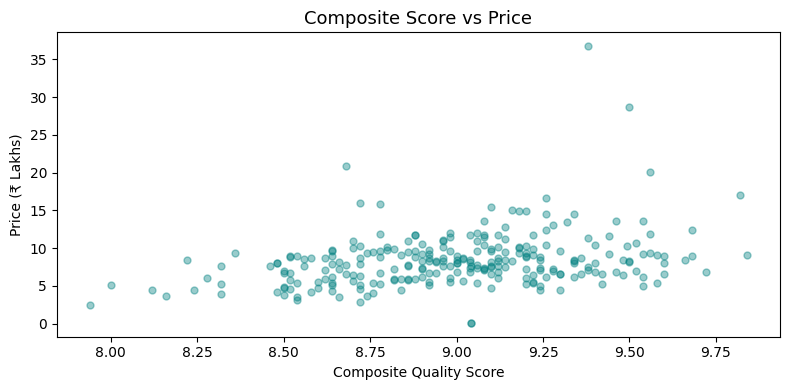

In [12]:
# Average of all 6 quality scores → single signal
df['Composite_Score'] = df[[
    'Overall Quality Score', 'Engine Score', 'Systems Score',
    'Interior Score', 'Exterior Score', 'Wear Score'
]].mean(axis=1).round(3)

print('Composite Score stats:')
print(df['Composite_Score'].describe())

# Scatter: Composite Score vs Price
plt.figure(figsize=(8, 4))
plt.scatter(df['Composite_Score'], df['Price (INR)'] / 1e5, alpha=0.4, color='teal', s=25)
plt.xlabel('Composite Quality Score')
plt.ylabel('Price (₹ Lakhs)')
plt.title('Composite Score vs Price')
plt.tight_layout()
plt.savefig('plot_06_composite_vs_price.png', dpi=150)
plt.show()

### 4.2 KM Per Year (Usage Intensity)

KM per year stats:
count      257.000000
mean     16081.412451
std       7956.211446
min       4000.000000
25%      10667.000000
50%      14500.000000
75%      19000.000000
max      49000.000000
Name: km_per_year, dtype: float64


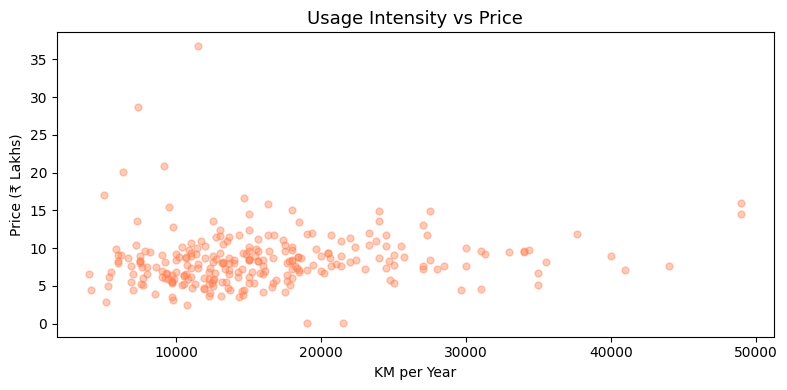

In [13]:
# Avoid division by zero for brand-new cars (Car Age = 0)
df['km_per_year'] = (df['Kilometres Driven'] / df['Car Age (years)'].replace(0, 1)).round(0).astype(int)

print('KM per year stats:')
print(df['km_per_year'].describe())

plt.figure(figsize=(8, 4))
plt.scatter(df['km_per_year'], df['Price (INR)'] / 1e5, alpha=0.4, color='coral', s=25)
plt.xlabel('KM per Year')
plt.ylabel('Price (₹ Lakhs)')
plt.title('Usage Intensity vs Price')
plt.tight_layout()
plt.savefig('plot_07_km_per_year_vs_price.png', dpi=150)
plt.show()

---
## 5. Encoding Categorical Columns

In [14]:
# Map ordinal columns manually (preserves natural order)
owner_map = {'1st Owner': 1, '2nd Owner': 2, '3rd Owner': 3}
df['Number of Previous Owners'] = df['Number of Previous Owners'].map(owner_map)

dep_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}
df['Depreciation_Category'] = df['Depreciation_Category'].map(dep_map)

binary_map = {'No': 0, 'Yes': 1}
df['Meter Tampered']  = df['Meter Tampered'].map(binary_map)
df['Flooded']         = df['Flooded'].map(binary_map)

df['Insurance Type']     = df['Insurance Type'].map({'Third Party': 0, 'Comprehensive': 1})
df['Transmission Type']  = df['Transmission Type'].map({'Manual': 0, 'Automatic': 1})
df['BS Norm']            = df['BS Norm'].map({'Unknown': 0, 'BSIV': 1, 'BSVI': 2})

# Fuel Type — Label Encode (no natural order)
le_fuel = LabelEncoder()
df['Fuel Type'] = le_fuel.fit_transform(df['Fuel Type'])
print('Fuel Type encoding:', dict(zip(le_fuel.classes_, le_fuel.transform(le_fuel.classes_))))

# Brand — Label Encode
le_brand = LabelEncoder()
df['Brand'] = le_brand.fit_transform(df['Brand'])
print('Brand encoding:', dict(zip(le_brand.classes_, le_brand.transform(le_brand.classes_))))

# Model — Label Encode
le_model = LabelEncoder()
df['Model'] = le_model.fit_transform(df['Model'].astype(str))

# Transmission Subtype — Label Encode
le_trans_sub = LabelEncoder()
df['Transmission Subtype'] = le_trans_sub.fit_transform(df['Transmission Subtype'])

print('\nAll dtypes after encoding:')
print(df.dtypes)

Fuel Type encoding: {'Cng': np.int64(0), 'Diesel': np.int64(1), 'Electric': np.int64(2), 'Hybrid': np.int64(3), 'Petrol': np.int64(4)}
Brand encoding: {'Audi': np.int64(0), 'BMW': np.int64(1), 'Ford': np.int64(2), 'Honda': np.int64(3), 'Hyundai': np.int64(4), 'Jeep': np.int64(5), 'Kia': np.int64(6), 'MG Motors': np.int64(7), 'Mahindra': np.int64(8), 'Maruti Suzuki': np.int64(9), 'Nissan': np.int64(10), 'Renault': np.int64(11), 'Skoda': np.int64(12), 'Tata': np.int64(13), 'Volkswagen': np.int64(14)}

All dtypes after encoding:
Brand                          int64
Model                          int64
Make Year                      int64
Car Age (years)                int64
Fuel Type                      int64
BS Norm                        int64
Transmission Type              int64
Transmission Subtype           int64
Kilometres Driven              int64
Number of Previous Owners      int64
Insurance Type                 int64
Overall Quality Score        float64
Engine Score            

---
## 6. Select Final Features

In [15]:
TARGET = 'Price (INR)'

FEATURES = [
    # Identity
    'Brand',
    'Model',
    # Age & Usage
    'Make Year',
    'Car Age (years)',
    'Kilometres Driven',
    'km_per_year',
    # Mechanical
    'Fuel Type',
    'Transmission Type',
    'Transmission Subtype',
    'BS Norm',
    # Ownership & Insurance
    'Number of Previous Owners',
    'Insurance Type',
    # Quality Scores
    'Overall Quality Score',
    'Engine Score',
    'Systems Score',
    'Interior Score',
    'Exterior Score',
    'Wear Score',
    'Composite_Score',
    # Derived value signals
    'Value_Score',
    'Depreciation_Category',
    # Risk flags
    'Meter Tampered',
    'Flooded',
]

X = df[FEATURES]
y = df[TARGET]

print(f'Feature matrix shape : {X.shape}')
print(f'Target shape         : {y.shape}')
print(f'Features selected    : {len(FEATURES)}')
X.head(3)

Feature matrix shape : (257, 23)
Target shape         : (257,)
Features selected    : 23


,Brand,Model,Make Year,Car Age (years),Kilometres Driven,km_per_year,Fuel Type,Transmission Type,Transmission Subtype,BS Norm,...,Engine Score,Systems Score,Interior Score,Exterior Score,Wear Score,Composite_Score,Value_Score,Depreciation_Category,Meter Tampered,Flooded
0,13,20,2021,4,99000,24750,4,0,4,0,...,9.5,9.3,8.0,8.8,8.7,8.86,7.0,3,0,0
1,13,20,2021,5,63000,12600,1,1,0,2,...,9.7,9.5,8.8,7.7,8.6,8.86,6.2,3,0,0
2,4,33,2019,6,66000,11000,4,1,2,1,...,9.8,9.5,7.8,8.1,8.0,8.64,7.9,3,0,0


---
## 7. Train / Test Split & Scaling

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train set : {X_train.shape}')
print(f'Test set  : {X_test.shape}')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURES)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=FEATURES)

print('\nScaled X_train sample:')
X_train_scaled.head(3)

Train set : (205, 23)
Test set  : (52, 23)

Scaled X_train sample:


,Brand,Model,Make Year,Car Age (years),Kilometres Driven,km_per_year,Fuel Type,Transmission Type,Transmission Subtype,BS Norm,...,Engine Score,Systems Score,Interior Score,Exterior Score,Wear Score,Composite_Score,Value_Score,Depreciation_Category,Meter Tampered,Flooded
0,1.018951,-0.275486,0.024468,-0.107246,-0.387302,-0.456168,0.765798,1.076055,-1.657208,-1.989484,...,0.531465,-0.149747,-1.057194,-0.253578,-0.386455,-0.513415,0.159228,-0.665017,-0.099258,-0.099258
1,-0.935854,1.129354,0.442465,-0.530042,-1.338715,-1.226800,0.765798,1.076055,1.033704,0.756942,...,1.095974,1.355060,1.575091,1.602975,0.945028,1.672159,1.280510,-0.665017,-0.099258,-0.099258
2,1.577466,0.005482,0.442465,-0.530042,-1.185261,-1.018491,0.765798,1.076055,-2.329936,0.756942,...,1.095974,1.054099,1.224119,1.046009,0.057373,1.081463,0.782163,-0.665017,-0.099258,-0.099258


---
## 8. Save Prepared Dataset & Encoders

In [17]:
import joblib

# Save train/test splits
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv',  index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv',   index=False)

# Save scaled versions
X_train_scaled.to_csv('X_train_scaled.csv', index=False)
X_test_scaled.to_csv('X_test_scaled.csv',   index=False)

# Save scaler and encoders for use in Stage 5 (deployment)
joblib.dump(scaler,       'scaler.pkl')
joblib.dump(le_fuel,      'le_fuel.pkl')
joblib.dump(le_brand,     'le_brand.pkl')
joblib.dump(le_model,     'le_model.pkl')
joblib.dump(le_trans_sub, 'le_trans_sub.pkl')
joblib.dump(FEATURES,     'feature_names.pkl')

# Save cleaned full dataset
df[FEATURES + [TARGET]].to_csv('prepared_dataset.csv', index=False)

print('Saved files:')
print('  prepared_dataset.csv')
print('  X_train.csv, X_test.csv, y_train.csv, y_test.csv')
print('  X_train_scaled.csv, X_test_scaled.csv')
print('  scaler.pkl, le_fuel.pkl, le_brand.pkl, le_model.pkl')
print('  le_trans_sub.pkl, feature_names.pkl')

Saved files:
  prepared_dataset.csv
  X_train.csv, X_test.csv, y_train.csv, y_test.csv
  X_train_scaled.csv, X_test_scaled.csv
  scaler.pkl, le_fuel.pkl, le_brand.pkl, le_model.pkl
  le_trans_sub.pkl, feature_names.pkl


---
## 9. Final Summary

In [18]:
print('='*55)
print('         STAGE 3 SUMMARY')
print('='*55)
print(f'Original rows            : 269')
print(f'Rows after cleaning      : {len(df)}')
print(f'Rows dropped             : {269 - len(df)}')
print(f'Original columns         : 32')
print(f'Columns after drop       : {len(df.columns)}')
print(f'Final features for model : {len(FEATURES)}')
print(f'Target                   : Price (INR)')
print(f'Train rows               : {len(X_train)}')
print(f'Test rows                : {len(X_test)}')
print(f'Missing values remaining : {df[FEATURES].isnull().sum().sum()}')
print('='*55)

         STAGE 3 SUMMARY
Original rows            : 269
Rows after cleaning      : 257
Rows dropped             : 12
Original columns         : 32
Columns after drop       : 24
Final features for model : 23
Target                   : Price (INR)
Train rows               : 205
Test rows                : 52
Missing values remaining : 0
